# DCF（现金流折现）估值模型教程

本教程将带你深入了解 **Discounted Cash Flow (DCF)** 估值方法，并使用真实股票数据进行实践。

## 📚 学习目标

1. 理解 DCF 的核心原理
2. 掌握关键参数的设定
3. 使用 `valueinvest` 库获取真实数据
4. 进行敏感性分析
5. 理解 DCF 的局限性和适用场景

---

> 本教程使用 [ValueInvest](https://github.com/wangzhe3224/valueinvest) 库

## 1. DCF 基础概念

### 什么是 DCF？

DCF（Discounted Cash Flow，现金流折现）是一种绝对估值方法，核心思想是：

**一家公司的价值 = 未来所有现金流的现值之和**

### 核心公式

$$\text{企业价值} = \sum_{t=1}^{n} \frac{FCF_t}{(1+r)^t} + \frac{TV}{(1+r)^n}$$

其中：
- $FCF_t$ = 第 t 年的自由现金流
- $r$ = 折现率（WACC）
- $n$ = 预测期（通常 10 年）
- $TV$ = 终值（Terminal Value）

### 终值计算

使用 **Gordon Growth Model**：

$$TV = \frac{FCF_n \times (1 + g)}{r - g}$$

- $g$ = 永续增长率（通常 2-3%）

In [1]:
# 导入必要的库
import sys
sys.path.insert(0, '..')  # 添加父目录到路径

from valueinvest import Stock, ValuationEngine
from valueinvest.valuation.dcf import DCF, ReverseDCF
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 库加载成功")

✓ 库加载成功


## 2. 获取真实股票数据

我们使用 `valueinvest` 库获取真实股票数据。支持：
- **A股**：通过 AKShare（免费）
- **美股**：通过 yfinance（免费）

In [2]:
# 获取苹果公司 (AAPL) 数据
ticker = "AAPL"
print(f"正在获取 {ticker} 数据...\n")

stock = Stock.from_api(ticker)

# 显示基本信息
print("=" * 60)
print(f"公司：{stock.name} ({stock.ticker})")
print("=" * 60)
print(f"当前股价：${stock.current_price:.2f}")
print(f"总股数：{stock.shares_outstanding/1e9:.2f}B")
print(f"市值：${stock.market_cap/1e9:.2f}B")
print(f"\n财务数据：")
print(f"  自由现金流 (FCF)：${stock.fcf/1e9:.2f}B")
print(f"  净债务：${stock.net_debt/1e9:.2f}B")
print(f"  每股收益 (EPS)：${stock.eps:.2f}")
print(f"  每股净资产 (BVPS)：${stock.bvps:.2f}")

正在获取 AAPL 数据...

公司：Apple Inc. (AAPL)
当前股价：$255.26
总股数：14.68B
市值：$3747.58B

财务数据：
  自由现金流 (FCF)：$98.77B
  净债务：$0.00B
  每股收益 (EPS)：$7.90
  每股净资产 (BVPS)：$6.00


## 3. 理解 DCF 的关键参数

DCF 模型需要设定 4 个关键参数，这些参数会显著影响估值结果：

In [3]:
# DCF 关键参数设定

print("📊 DCF 关键参数")
print("=" * 60)

# 1. 增长率 (Years 1-5)
# 通常是公司历史增长率和行业预期的结合
# 苹果是成熟公司，假设未来5年年均增长 8%
growth_rate_1_5 = 8.0  # %
print(f"1. 增长率 (Years 1-5): {growth_rate_1_5}%")
print(f"   - 反映公司未来5年的预期增长")
print(f"   - 需要参考历史增长、行业趋势、公司战略")

# 2. 增长率 (Years 6-10)
# 随着公司成熟，增长率通常会放缓
growth_rate_6_10 = 4.0  # %
print(f"\n2. 增长率 (Years 6-10): {growth_rate_6_10}%")
print(f"   - 后期增长通常会放缓")
print(f"   - 一般设为前期增长率的一半左右")

# 3. 终值增长率 (Terminal Growth Rate)
# 永续增长率，通常等于长期通胀率或GDP增长率
terminal_growth = 2.5  # %
print(f"\n3. 终值增长率: {terminal_growth}%")
print(f"   - 代表公司进入稳定期后的永续增长")
print(f"   - 通常设定为 2-3%（接近长期通胀/GDP增长）")

# 4. 折现率 (Discount Rate / WACC)
# 资金的机会成本，通常使用 WACC 或要求的回报率
discount_rate = 10.0  # %
print(f"\n4. 折现率 (WACC): {discount_rate}%")
print(f"   - 代表投资者的机会成本")
print(f"   - 可以用 CAPM 计算，或简单用 8-12%")

print("\n" + "=" * 60)
print("⚠️  参数设定提示：")
print("   - 这些参数会极大影响估值结果")
print("   - 应该进行敏感性分析（稍后演示）")
print("   - 折现率必须大于终值增长率，否则模型无意义")

📊 DCF 关键参数
1. 增长率 (Years 1-5): 8.0%
   - 反映公司未来5年的预期增长
   - 需要参考历史增长、行业趋势、公司战略

2. 增长率 (Years 6-10): 4.0%
   - 后期增长通常会放缓
   - 一般设为前期增长率的一半左右

3. 终值增长率: 2.5%
   - 代表公司进入稳定期后的永续增长
   - 通常设定为 2-3%（接近长期通胀/GDP增长）

4. 折现率 (WACC): 10.0%
   - 代表投资者的机会成本
   - 可以用 CAPM 计算，或简单用 8-12%

⚠️  参数设定提示：
   - 这些参数会极大影响估值结果
   - 应该进行敏感性分析（稍后演示）
   - 折现率必须大于终值增长率，否则模型无意义


## 4. 运行 DCF 估值

现在让我们使用这些参数进行 DCF 估值：

In [4]:
# 设置估值参数
stock.growth_rate_1_5 = growth_rate_1_5
stock.growth_rate_6_10 = growth_rate_6_10
stock.terminal_growth = terminal_growth
stock.discount_rate = discount_rate

# 方法1：使用 ValuationEngine
engine = ValuationEngine()
result = engine.run_single(stock, "dcf")

# 显示结果
print("=" * 60)
print(f"DCF 估值结果：{stock.name} ({stock.ticker})")
print("=" * 60)

if result.fair_value:
    print(f"\n💰 估值结果")
    print(f"   内在价值：${result.fair_value:.2f}")
    print(f"   当前股价：${result.current_price:.2f}")
    print(f"   溢价/折价：{result.premium_discount:+.1f}%")
    print(f"   评估：{result.assessment}")
    
    if result.fair_value_range:
        print(f"\n📊 估值区间")
        print(f"   保守：${result.fair_value_range.low:.2f}")
        print(f"   基准：${result.fair_value_range.base:.2f}")
        print(f"   乐观：${result.fair_value_range.high:.2f}")
    
    print(f"\n📈 详细信息")
    print(f"   FCF 现值：${result.components['pv_fcf']/1e9:.2f}B")
    print(f"   终值现值：${result.components['pv_terminal']/1e9:.2f}B")
    print(f"   企业价值：${result.components['enterprise_value']/1e9:.2f}B")
    print(f"   股权价值：${result.components['equity_value']/1e9:.2f}B")
    print(f"   终值占比：{result.details['terminal_value_pct']:.1f}%")
    
    print(f"\n📝 分析要点")
    for analysis in result.analysis:
        print(f"   • {analysis}")
    
    print(f"\n🎯 置信度：{result.confidence}")
else:
    print(f"❌ 估值失败：{result.error}")

DCF 估值结果：Apple Inc. (AAPL)

💰 估值结果
   内在价值：$121.23
   当前股价：$255.26
   溢价/折价：-52.5%
   评估：Overvalued

📊 估值区间
   保守：$82.88
   基准：$121.23
   乐观：$201.41

📈 详细信息
   FCF 现值：$849.51B
   终值现值：$930.32B
   企业价值：$1779.83B
   股权价值：$1779.83B
   终值占比：52.3%

📝 分析要点
   • 10-year DCF with terminal value
   • Terminal Value represents 52.3% of total value
   • FCF Year 10: 176.56B
   • Note: net_debt (Net Debt)

🎯 置信度：Medium


## 5. 手动计算 DCF（理解每一步）

为了深入理解 DCF，让我们手动计算每一步：

In [5]:
# 手动 DCF 计算

def manual_dcf(fcf, shares, net_debt, g1, g2, g_term, r):
    """
    手动计算 DCF
    
    参数:
    - fcf: 当前自由现金流
    - shares: 总股数
    - net_debt: 净债务
    - g1: 前5年增长率 (小数)
    - g2: 后5年增长率 (小数)
    - g_term: 终值增长率 (小数)
    - r: 折现率 (小数)
    """
    
    # 1. 计算未来10年的 FCF
    projected_fcf = fcf
    cash_flows = []
    
    for year in range(1, 11):
        if year <= 5:
            projected_fcf *= (1 + g1)
        else:
            projected_fcf *= (1 + g2)
        
        # 折现到现值
        pv = projected_fcf / ((1 + r) ** year)
        cash_flows.append({
            'year': year,
            'fcf': projected_fcf,
            'pv': pv
        })
    
    # 2. 计算 FCF 现值总和
    total_pv_fcf = sum(cf['pv'] for cf in cash_flows)
    
    # 3. 计算终值
    fcf_year_10 = cash_flows[-1]['fcf']
    terminal_value = (fcf_year_10 * (1 + g_term)) / (r - g_term)
    pv_terminal = terminal_value / ((1 + r) ** 10)
    
    # 4. 计算企业价值
    enterprise_value = total_pv_fcf + pv_terminal
    
    # 5. 计算股权价值
    equity_value = enterprise_value - net_debt
    
    # 6. 计算每股内在价值
    intrinsic_value = equity_value / shares
    
    return {
        'cash_flows': cash_flows,
        'total_pv_fcf': total_pv_fcf,
        'terminal_value': terminal_value,
        'pv_terminal': pv_terminal,
        'enterprise_value': enterprise_value,
        'equity_value': equity_value,
        'intrinsic_value': intrinsic_value,
        'terminal_pct': pv_terminal / enterprise_value * 100
    }

# 执行计算
result_manual = manual_dcf(
    fcf=stock.fcf,
    shares=stock.shares_outstanding,
    net_debt=stock.net_debt,
    g1=growth_rate_1_5/100,
    g2=growth_rate_6_10/100,
    g_term=terminal_growth/100,
    r=discount_rate/100
)

# 创建现金流表格
df_flows = pd.DataFrame(result_manual['cash_flows'])
df_flows['fcf_billion'] = df_flows['fcf'] / 1e9
df_flows['pv_billion'] = df_flows['pv'] / 1e9

print("\n📊 未来10年现金流预测")
print("=" * 60)
print(df_flows[['year', 'fcf_billion', 'pv_billion']].to_string(index=False, float_format='%.2f'))

print(f"\n💰 估值构成")
print("=" * 60)
print(f"FCF 现值总和：${result_manual['total_pv_fcf']/1e9:.2f}B")
print(f"终值：${result_manual['terminal_value']/1e9:.2f}B")
print(f"终值现值：${result_manual['pv_terminal']/1e9:.2f}B")
print(f"企业价值：${result_manual['enterprise_value']/1e9:.2f}B")
print(f"股权价值：${result_manual['equity_value']/1e9:.2f}B")
print(f"\n每股内在价值：${result_manual['intrinsic_value']:.2f}")
print(f"终值占比：{result_manual['terminal_pct']:.1f}%")


📊 未来10年现金流预测
 year  fcf_billion  pv_billion
    1       106.67       96.97
    2       115.20       95.21
    3       124.42       93.48
    4       134.37       91.78
    5       145.12       90.11
    6       150.93       85.19
    7       156.96       80.55
    8       163.24       76.15
    9       169.77       72.00
   10       176.56       68.07

💰 估值构成
FCF 现值总和：$849.51B
终值：$2413.01B
终值现值：$930.32B
企业价值：$1779.83B
股权价值：$1779.83B

每股内在价值：$121.23
终值占比：52.3%


## 6. 可视化现金流预测

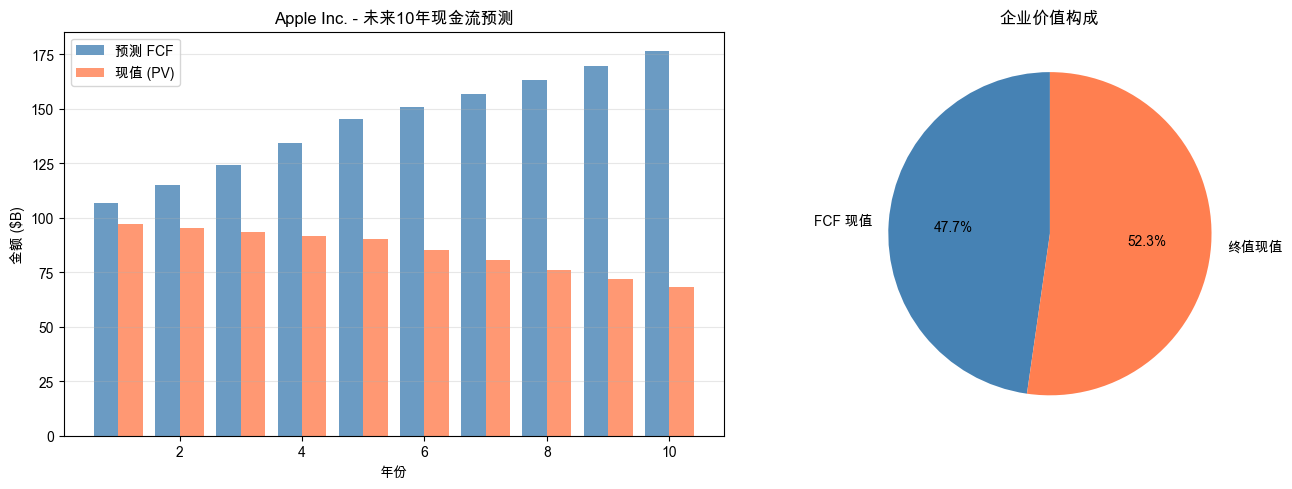


💡 关键洞察：
   终值占企业价值的 52.3%
   ✓ 终值占比合理，估值相对稳健


In [6]:
# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：FCF 和 PV
ax1 = axes[0]
years = df_flows['year']
ax1.bar(years - 0.2, df_flows['fcf_billion'], 0.4, label='预测 FCF', color='steelblue', alpha=0.8)
ax1.bar(years + 0.2, df_flows['pv_billion'], 0.4, label='现值 (PV)', color='coral', alpha=0.8)
ax1.set_xlabel('年份')
ax1.set_ylabel('金额 ($B)')
ax1.set_title(f'{stock.name} - 未来10年现金流预测')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 右图：估值构成
ax2 = axes[1]
components = ['FCF 现值', '终值现值']
values = [result_manual['total_pv_fcf']/1e9, result_manual['pv_terminal']/1e9]
colors = ['steelblue', 'coral']
ax2.pie(values, labels=components, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('企业价值构成')

plt.tight_layout()
plt.show()

print(f"\n💡 关键洞察：")
print(f"   终值占企业价值的 {result_manual['terminal_pct']:.1f}%")
if result_manual['terminal_pct'] > 60:
    print(f"   ⚠️  终值占比过高，估值对终值增长率假设非常敏感")
else:
    print(f"   ✓ 终值占比合理，估值相对稳健")

## 7. 敏感性分析

DCF 对关键参数非常敏感。让我们分析不同参数假设下的估值范围：

In [7]:
# 敏感性分析

# 定义参数范围
growth_rates = [5, 8, 11, 14]  # 前5年增长率
discount_rates = [8, 10, 12]   # 折现率

# 创建敏感性矩阵
sensitivity_matrix = []

for g in growth_rates:
    row = []
    for r in discount_rates:
        # 使用 DCF 类计算
        dcf = DCF(growth_1_5=g, growth_6_10=g*0.5, 
                  terminal_growth=terminal_growth, discount_rate=r)
        result_sens = dcf.calculate(stock)
        if result_sens.fair_value:
            row.append(result_sens.fair_value)
        else:
            row.append(None)
    sensitivity_matrix.append(row)

# 创建 DataFrame
df_sensitivity = pd.DataFrame(
    sensitivity_matrix,
    index=[f'增长 {g}%' for g in growth_rates],
    columns=[f'折现 {r}%' for r in discount_rates]
)

print("\n📊 敏感性分析矩阵 - 内在价值 ($)")
print("=" * 60)
print(df_sensitivity.to_string(float_format='%.2f'))

print(f"\n当前股价：${stock.current_price:.2f}")
print(f"\n💡 分析：")
print(f"   - 增长率越高，估值越高")
print(f"   - 折现率越高，估值越低")
print(f"   - 估值范围：${df_sensitivity.min().min():.2f} - ${df_sensitivity.max().max():.2f}")


📊 敏感性分析矩阵 - 内在价值 ($)
        折现 8%  折现 10%  折现 12%
增长 5%  139.84  102.18   80.40
增长 8%  167.53  121.23   94.56
增长 11% 200.42  143.74  111.19
增长 14% 239.37  170.26  130.71

当前股价：$255.26

💡 分析：
   - 增长率越高，估值越高
   - 折现率越高，估值越低
   - 估值范围：$80.40 - $239.37


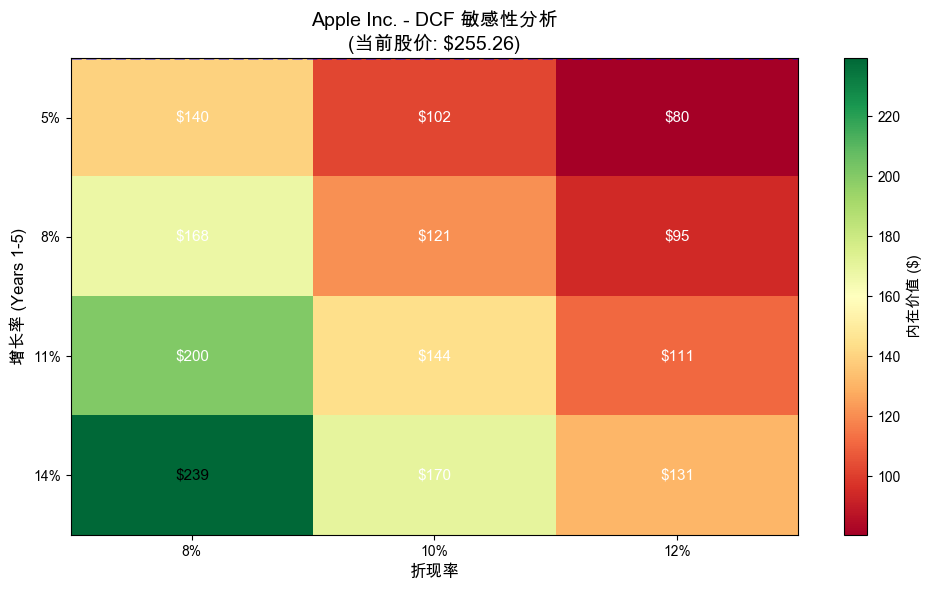

In [8]:
# 可视化敏感性分析
fig, ax = plt.subplots(figsize=(10, 6))

# 热力图
im = ax.imshow(sensitivity_matrix, cmap='RdYlGn', aspect='auto')

# 设置坐标轴
ax.set_xticks(range(len(discount_rates)))
ax.set_yticks(range(len(growth_rates)))
ax.set_xticklabels([f'{r}%' for r in discount_rates])
ax.set_yticklabels([f'{g}%' for g in growth_rates])

# 添加数值标签
for i in range(len(growth_rates)):
    for j in range(len(discount_rates)):
        value = sensitivity_matrix[i][j]
        if value:
            color = 'white' if abs(value - stock.current_price) > 30 else 'black'
            ax.text(j, i, f'${value:.0f}', ha='center', va='center', 
                   color=color, fontsize=11, fontweight='bold')

# 添加当前股价参考线
ax.axhline(y=-0.5, color='blue', linestyle='--', linewidth=2, alpha=0.5)

ax.set_xlabel('折现率', fontsize=12)
ax.set_ylabel('增长率 (Years 1-5)', fontsize=12)
ax.set_title(f'{stock.name} - DCF 敏感性分析\n(当前股价: ${stock.current_price:.2f})', fontsize=14)

# 添加颜色条
cbar = plt.colorbar(im)
cbar.set_label('内在价值 ($)', fontsize=11)

plt.tight_layout()
plt.show()

## 8. Reverse DCF - 市场预期什么？

Reverse DCF 不预测未来，而是回答：**当前股价隐含的增长预期是什么？**

In [9]:
# Reverse DCF 分析
reverse_result = engine.run_single(stock, "reverse_dcf")

print("\n🔄 Reverse DCF 分析")
print("=" * 60)

if reverse_result.details:
    implied_growth = reverse_result.details.get('implied_growth_1_5', 0)
    implied_growth_6_10 = reverse_result.details.get('implied_growth_6_10', 0)
    
    print(f"\n当前股价 ${stock.current_price:.2f} 隐含的预期：")
    print(f"   前5年年均增长：{implied_growth:.1f}%")
    print(f"   后5年年均增长：{implied_growth_6_10:.1f}%")
    
    print(f"\n📝 分析：")
    for analysis in reverse_result.analysis:
        print(f"   • {analysis}")
    
    # 与历史增长对比
    print(f"\n💡 思考：")
    if implied_growth > 15:
        print(f"   ⚠️  市场预期高增长 ({implied_growth:.1f}%)，需要验证是否可持续")
    elif implied_growth < 5:
        print(f"   市场预期低增长 ({implied_growth:.1f}%)，可能是价值机会或衰退预期")
    else:
        print(f"   市场预期中等增长 ({implied_growth:.1f}%)，相对合理")
    
    print(f"\n   你需要判断：公司能否实现 {implied_growth:.1f}% 的年增长？")
else:
    print(f"❌ 分析失败：{reverse_result.error}")


🔄 Reverse DCF 分析

当前股价 $255.26 隐含的预期：
   前5年年均增长：21.3%
   后5年年均增长：10.6%

📝 分析：
   • Market prices in 21.3% annual growth for years 1-5
   • Years 6-10 growth implied at 10.6%
   • Note: net_debt (Net Debt)
   • Sensitivity range: 16.3% to 26.3% growth

💡 思考：
   ⚠️  市场预期高增长 (21.3%)，需要验证是否可持续

   你需要判断：公司能否实现 21.3% 的年增长？


## 9. A股案例 - 伊利股份

让我们用相同方法分析一只 A 股：

In [10]:
# 分析 A 股 - 伊利股份 (600887)
ticker_cn = "600887"
print(f"正在获取 {ticker_cn} (伊利股份) 数据...\n")

try:
    stock_cn = Stock.from_api(ticker_cn)
    
    print("=" * 60)
    print(f"公司：{stock_cn.name} ({stock_cn.ticker})")
    print("=" * 60)
    print(f"当前股价：¥{stock_cn.current_price:.2f}")
    print(f"市值：¥{stock_cn.market_cap/1e8:.2f}亿")
    print(f"自由现金流：¥{stock_cn.fcf/1e8:.2f}亿")
    print(f"每股收益：¥{stock_cn.eps:.2f}")
    
    # 设置 A 股参数（通常增长率较低，折现率考虑中国市场风险溢价）
    stock_cn.growth_rate_1_5 = 6.0   # A股成熟公司通常增长较慢
    stock_cn.growth_rate_6_10 = 3.0
    stock_cn.terminal_growth = 2.0
    stock_cn.discount_rate = 12.0    # 中国市场风险溢价较高
    
    # 运行 DCF
    result_cn = engine.run_single(stock_cn, "dcf")
    
    if result_cn.fair_value:
        print(f"\n💰 DCF 估值结果")
        print(f"   内在价值：¥{result_cn.fair_value:.2f}")
        print(f"   溢价/折价：{result_cn.premium_discount:+.1f}%")
        print(f"   评估：{result_cn.assessment}")
        print(f"   终值占比：{result_cn.details['terminal_value_pct']:.1f}%")
    else:
        print(f"\n❌ 估值失败：{result_cn.error}")
        
except Exception as e:
    print(f"❌ 获取数据失败：{e}")
    print("\n提示：确保已安装 AKShare: pip install valueinvest[ashare]")

正在获取 600887 (伊利股份) 数据...

公司：伊利股份 (600887)
当前股价：¥26.71
市值：¥1689.50亿
自由现金流：¥71.77亿
每股收益：¥1.65

💰 DCF 估值结果
   内在价值：¥4.71
   溢价/折价：-82.4%
   评估：Overvalued
   终值占比：41.4%


## 10. DCF 的局限性和最佳实践

### ⚠️ 局限性

1. **对参数极度敏感**
   - 增长率、折现率的小变化会导致估值大变化
   - 终值往往占总价值的 50-70%

2. **不适用的情况**
   - 负现金流的公司（早期初创）
   - 周期性行业（现金流波动大）
   - 银行、保险（现金流定义不同）

3. **假设外推风险**
   - 历史增长不一定持续
   - 行业格局可能变化

### ✅ 最佳实践

1. **保守假设**
   - 增长率不超过行业平均
   - 折现率考虑风险溢价

2. **敏感性分析**
   - 测试不同参数组合
   - 得出估值区间而非单一值

3. **结合其他方法**
   - DCF + 相对估值（PE/PB）
   - Reverse DCF 验证市场预期

4. **关注质量**
   - FCF 质量（是否稳定、可持续）
   - 终值占比（<60% 较好）

In [ ]:
# 综合分析示例
print("\n📊 综合估值分析 - " + stock.name)
print("=" * 60)

# 运行多种估值方法
results_all = engine.run_all(stock)

# 筛选出有效结果
valid_results = [(r.method, r.fair_value, r.premium_discount) 
                 for r in results_all if r.fair_value and r.fair_value > 0]

if valid_results:
    df_results = pd.DataFrame(valid_results, 
                              columns=['方法', '内在价值', '溢价/折价%'])
    print(df_results.to_string(index=False, float_format=lambda x: f'{x:.2f}'))
    
    avg_value = np.mean([r[1] for r in valid_results])
    print(f"\n💡 平均估值：${avg_value:.2f}")
    print(f"   当前股价：${stock.current_price:.2f}")
    print(f"   平均溢价/折价：{((avg_value - stock.current_price)/stock.current_price*100):+.1f}%")

## 11. 总结

### 📌 关键要点

1. **DCF 核心**：公司价值 = 未来现金流的现值

2. **关键参数**：
   - 增长率（Years 1-5, 6-10）
   - 终值增长率（2-3%）
   - 折现率（8-12%）

3. **敏感性分析必不可少**

4. **Reverse DCF 帮助理解市场预期**

5. **结合多种估值方法**

### 🎯 实践建议

- 使用 `valueinvest` 库快速获取数据和估值
- 对关键参数进行敏感性分析
- 优先分析 FCF 稳定的成熟公司
- 将 DCF 作为估值的参考之一，而非唯一标准

---

**参考资料**：
- [ValueInvest GitHub](https://github.com/wangzhe3224/valueinvest)
- 《证券分析》- Benjamin Graham
- 《估值》- McKinsey

In [ ]:
# 保存分析报告
from datetime import datetime

report = f"""
DCF 估值分析报告
{'=' * 60}
生成时间：{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

股票：{stock.name} ({stock.ticker})
当前股价：${stock.current_price:.2f}

DCF 参数：
- 增长率 (Years 1-5): {growth_rate_1_5}%
- 增长率 (Years 6-10): {growth_rate_6_10}%
- 终值增长率: {terminal_growth}%
- 折现率: {discount_rate}%

估值结果：
- 内在价值：${result.fair_value:.2f}
- 溢价/折价：{result.premium_discount:+.1f}%
- 评估：{result.assessment}
- 终值占比：{result.details['terminal_value_pct']:.1f}%
- 置信度：{result.confidence}

Reverse DCF：
- 市场隐含增长 (Years 1-5): {reverse_result.details.get('implied_growth_1_5', 'N/A')}%

分析要点：
{chr(10).join(['- ' + a for a in result.analysis])}
"""

print(report)
print("\n✓ 分析完成！")
print(f"\n📚 更多教程和案例，请访问：https://github.com/wangzhe3224/valueinvest")